# Subreddit Cross-Analysis (Market Segmentation)
In this notebook, we compare the engagement and sentiment across different subreddits. Different communities (e.g., student communities vs. technology communities) likely have different views on the intersection of AI and Wikipedia. This is a classic Market Segmentation analysis.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

## 1. Load the Data
We need the processed dataset containing RoBERTa or RoBERTa sentiment scores to perform segment comparison.

In [10]:
try:
    df = pd.read_csv('../../data/processed/reddit_processed/reddit_with_sentiment.csv')
    print('Loaded processed sentiment data.')
    # If roberta_numeric or roberta_numeric is not present, raise error early
    if 'roberta_numeric' not in df.columns:
        print('WARNING: Sentiment scores not found in dataset. Run Sentiment Analysis notebook first.')
except FileNotFoundError:
    print('ERROR: Processed sentiment data not found. Please run the Sentiment Analysis notebook first to generate sentiment scores.')
    df = pd.DataFrame() # Create empty dataframe to prevent crashes

if not df.empty:
    print(f'Total posts loaded: {len(df)}')
    print(f'Unique subreddits: {df["subreddit"].unique()}')

Loaded processed sentiment data.
Total posts loaded: 684
Unique subreddits: ['wikipedia' 'ChatGPT' 'artificial']


## 2. Comparing Engagement by Subreddit
Which communities are most active in discussing Wikipedia and AI? We'll look at average upvote score and comment counts.

Subreddit Engagement Statistics:


,subreddit,total_posts,avg_score,avg_comments,median_score
0,ChatGPT,237,216.827004,55.810127,6.0
1,artificial,229,25.903930,16.685590,6.0
2,wikipedia,218,200.981651,12.903670,16.5


C:\Users\Sumithra\AppData\Local\Temp\ipykernel_24716\2748711254.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=engagement_stats, x='subreddit', y='avg_score', palette='Blues_d')


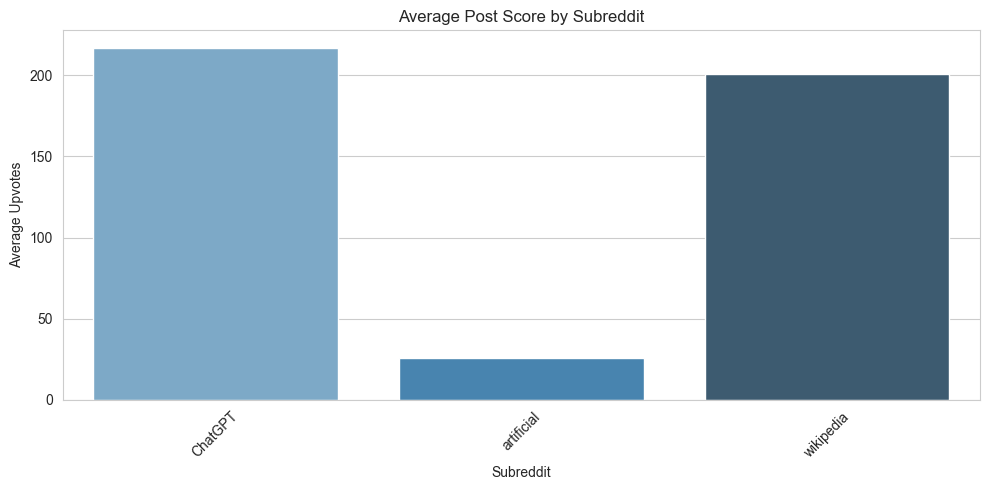

In [11]:
if not df.empty:
    # Calculate engagement metrics per subreddit
    engagement_stats = df.groupby('subreddit').agg(
        total_posts=('subreddit', 'count'),
        avg_score=('score', 'mean'),
        avg_comments=('num_comments', 'mean'),
        median_score=('score', 'median')
    ).reset_index().sort_values('total_posts', ascending=False)

    print('Subreddit Engagement Statistics:')
    display(engagement_stats)
    
    # Visualize Average Score by Subreddit
    plt.figure(figsize=(10, 5))
    sns.barplot(data=engagement_stats, x='subreddit', y='avg_score', palette='Blues_d')
    plt.title('Average Post Score by Subreddit')
    plt.ylabel('Average Upvotes')
    plt.xlabel('Subreddit')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## 3. Subreddit Sentiment Comparison
Are some communities significantly more positive or negative about AI's impact on Wikipedia? Let's compare their sentiment distributions using boxplots.

C:\Users\Sumithra\AppData\Local\Temp\ipykernel_24716\2328399395.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='subreddit', y='vader_compound', order=order, palette='Set2')


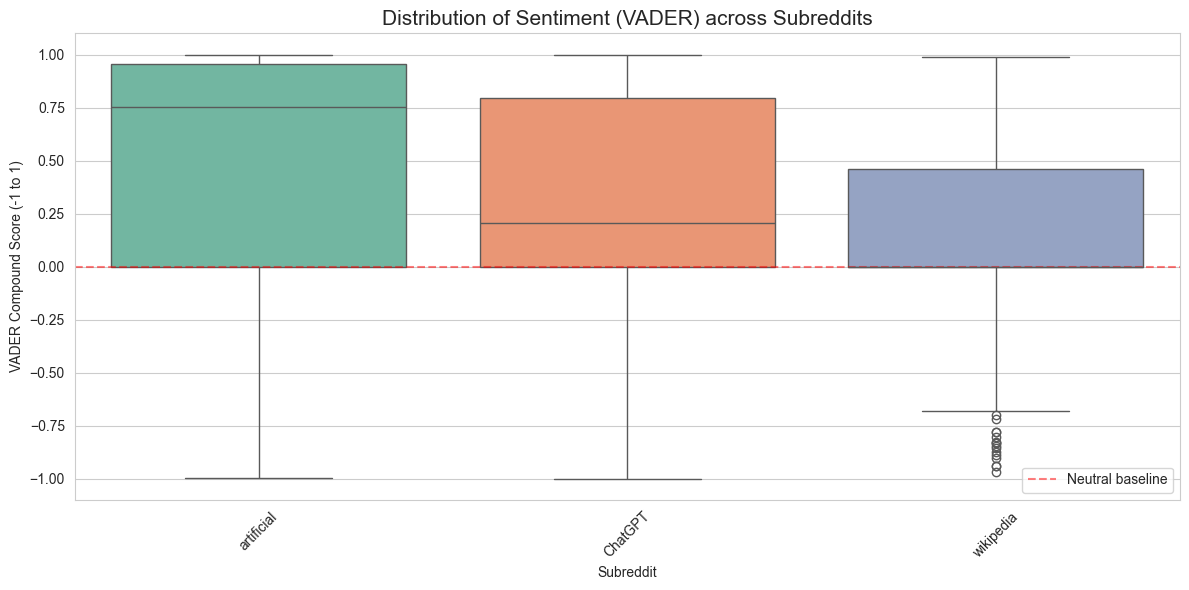

In [12]:
if not df.empty and 'vader_compound' in df.columns:
    order = df.groupby('subreddit')['vader_compound'].median().sort_values(ascending=False).index

    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df, x='subreddit', y='vader_compound', order=order, palette='Set2')
    
    # Add a horizontal line at 0 (neutral)
    plt.axhline(0, color='red', linestyle='--', alpha=0.5, label='Neutral baseline')
    
    plt.title('Distribution of Sentiment (VADER) across Subreddits', fontsize=15)
    plt.ylabel('VADER Compound Score (-1 to 1)')
    plt.xlabel('Subreddit')
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.savefig('../../reports/reddit_reports/subreddit_sentiment_boxplot_vader.png')
    plt.show()
else:
    print('Sentiment columns not found. Skipping plot.')

C:\Users\Sumithra\AppData\Local\Temp\ipykernel_24716\2198629166.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='subreddit', y='roberta_numeric', order=order, palette='Set2')


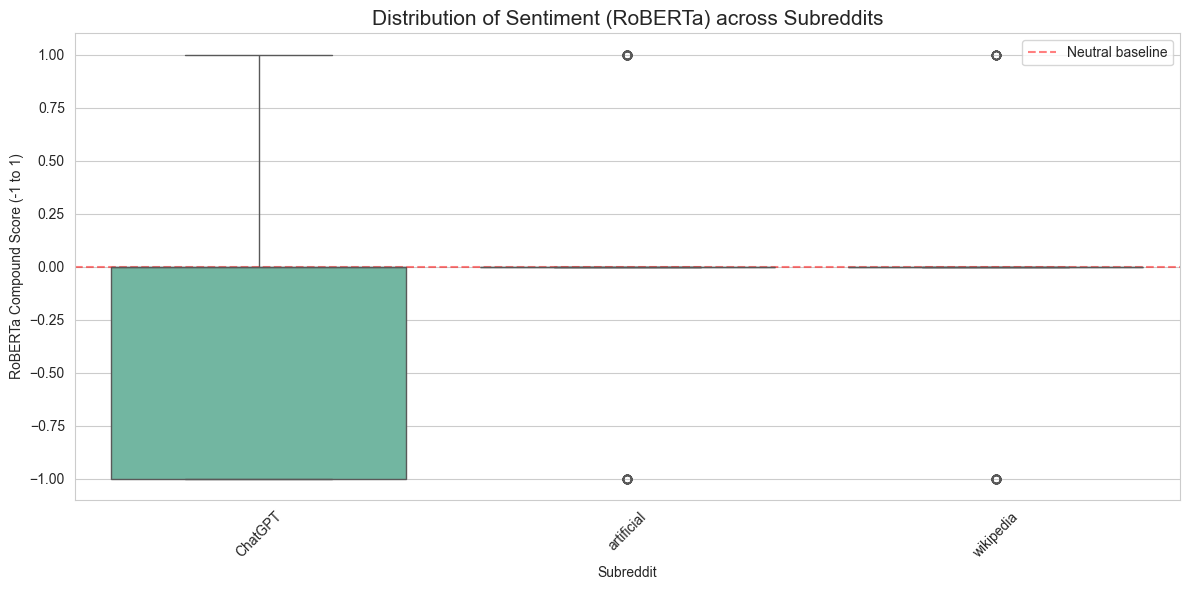

In [13]:
if not df.empty and 'roberta_numeric' in df.columns:
    # We'll use RoBERTa compound score for a continuous distribution plot
    # Sort subreddits by median sentiment to make the plot easier to read
    order = df.groupby('subreddit')['roberta_numeric'].median().sort_values(ascending=False).index

    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df, x='subreddit', y='roberta_numeric', order=order, palette='Set2')
    
    # Add a horizontal line at 0 (neutral)
    plt.axhline(0, color='red', linestyle='--', alpha=0.5, label='Neutral baseline')
    
    plt.title('Distribution of Sentiment (RoBERTa) across Subreddits', fontsize=15)
    plt.ylabel('RoBERTa Compound Score (-1 to 1)')
    plt.xlabel('Subreddit')
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.savefig('../../reports/reddit_reports/subreddit_sentiment_boxplot_roberta.png')
    plt.show()
else:
    print('Sentiment columns not found. Skipping plot.')

## 4. Sentiment Polarity Breakdown (Positive vs. Negative)
Instead of a continuous score, what percentage of posts in each subreddit are classified as definitively Positive vs Negative?

Sentiment Distribution % by Subreddit:


roberta_label,negative,neutral,positive
subreddit,,,
ChatGPT,38.8,49.8,11.4
artificial,10.5,73.8,15.7
wikipedia,13.8,79.8,6.4


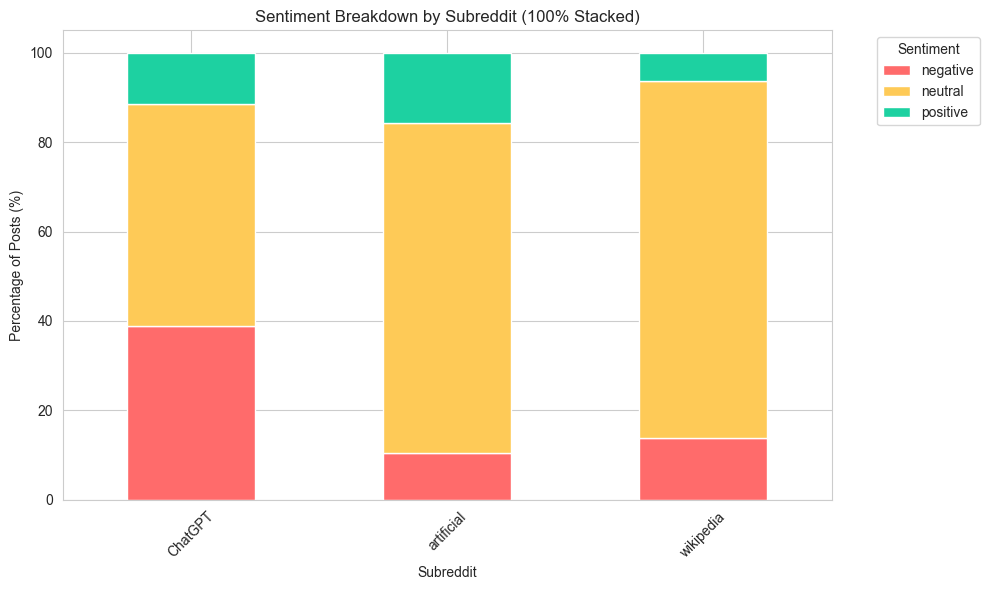

In [ ]:
if not df.empty and 'roberta_label' in df.columns:
    # percentage of positive, negative, and neutral posts per subreddit
    sentiment_pct = df.groupby(['subreddit', 'roberta_label']).size().unstack(fill_value=0)
    
    # counts to percentages (row percentages normalize across community size)
    sentiment_pct = sentiment_pct.div(sentiment_pct.sum(axis=1), axis=0) * 100
    
 
    if set(['negative', 'neutral', 'positive']).issubset(sentiment_pct.columns):
        sentiment_pct = sentiment_pct[['negative', 'neutral', 'positive']]
    
    print('Sentiment Distribution % by Subreddit:')
    display(sentiment_pct.round(1))


    sentiment_pct.plot(kind='bar', stacked=True, figsize=(10, 6))
    
    plt.title('Sentiment Breakdown by Subreddit (100% Stacked)')
    plt.ylabel('Percentage of Posts (%)')
    plt.xlabel('Subreddit')
    plt.legend(title='Sentiment', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('../../reports/reddit_reports/subreddit_sentiment_stacked.png')
    plt.show()
else:
    print('Sentiment labels not found. Skipping plot.')